# Test harness for `goCue_burst.burst_analysis`

Smoke-tests [goCue_burst.py](goCue_burst.py) on a single session/unit and previews the resulting
figure inline. `burst_analysis` is **imported**, not copied, so this notebook always exercises the
real function (unlike `session_combine/beh_go_cue_burst.ipynb`, which carries an older inline copy).

`burst_analysis(session, data_type, units=None)` writes one
`{session}_{unit_id}_burst_selected.pdf` per unit into
`session_dirs(session)['ephys_fig_dir_{data_type}']/burst/`, skipping units with `p_max < 0.5`
or `<= 20` trials surviving the drift cut.

**Before you run anything, three things to know:**

1. It calls `shutil.rmtree()` on the `burst/` output folder first, so testing one unit deletes
   every burst PDF already generated for that session.
2. `low_bound` / `up_bound` are assigned inside the first `if len(df) >= 10:` block but read by the
   second one, so a unit with a near-empty first-spike window can raise `NameError` (or silently
   reuse the previous unit's color scale).
3. It needs a per-session unit table (`*_soma_opto_tagging_summary.pkl` or
   `*_opto_tagging_metrics.pkl` under `opto_dir_{data_type}`). Step 1 below finds sessions that
   have one; if none do, run `session_preprocessing.py` or attach a processed data asset first.

In [1]:
import sys
import os
import glob
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from utils.beh_functions import session_dirs, get_session_tbl, get_unit_tbl
from utils.ephys_functions import load_drift
from utils.capsule_migration import capsule_directories
from goCue_burst import burst_analysis

%matplotlib inline

## 1. Find a session that can actually be tested

In [2]:
DERIVED_DIR = str(capsule_directories()['derived_dir'])

# Glob for the unit table rather than calling session_dirs() over a list of session ids --
# session_dirs() makedirs() the whole scratch tree for whatever session it is handed.
rows = []
for pkl in sorted(glob.glob(os.path.join(DERIVED_DIR, '*', 'behavior_*', 'ephys', 'opto', '*', '*.pkl'))):
    parts = pkl.split(os.sep)
    session, data_type, fname = parts[-5], parts[-2], parts[-1]
    if 'opto_tagging_summary' in fname or fname.endswith('opto_tagging_metrics.pkl'):
        rows.append({'session': session, 'data_type': data_type, 'file': fname})

ready = pd.DataFrame(rows, columns=['session', 'data_type', 'file']).drop_duplicates(['session', 'data_type'])
print(f'{len(ready)} session x data_type combinations have a unit table under {DERIVED_DIR}')
if ready.empty:
    print('Nothing to test against: run session_preprocessing.py for a session, or attach a data '
          'asset whose opto processing is already done, before running the cells below.')
ready

74 session x data_type combinations have a unit table under /root/capsule/scratch


,session,data_type,file
0,behavior_791174_2025-09-05_14-06-53,raw,behavior_791174_2025-09-05_14-06-53_opto_taggi...
2,behavior_792288_2025-08-26_11-41-18,raw,behavior_792288_2025-08-26_11-41-18_opto_taggi...
4,behavior_792288_2025-08-27_12-09-38,raw,behavior_792288_2025-08-27_12-09-38_opto_taggi...
6,behavior_792292_2025-08-13_14-47-17,raw,behavior_792292_2025-08-13_14-47-17_opto_taggi...
8,behavior_792292_2025-08-15_14-15-47,raw,behavior_792292_2025-08-15_14-15-47_opto_taggi...
...,...,...,...
133,behavior_844920_2026-06-11_11-27-15,raw,behavior_844920_2026-06-11_11-27-15_opto_taggi...
135,behavior_844920_2026-06-12_11-03-09,raw,behavior_844920_2026-06-12_11-03-09_opto_taggi...
137,behavior_848869_2026-05-12_08-51-54,raw,behavior_848869_2026-05-12_08-51-54_opto_taggi...
139,behavior_848869_2026-05-14_08-45-55,raw,behavior_848869_2026-05-14_08-45-55_opto_taggi...


## 2. Load the tables and see which units will be plotted

`DATA_TYPE` prefers `'curated'` and falls back to whatever step 1 found -- as of this writing the
attached scratch tree only has `raw` tables (`*_opto_tagging_metrics.pkl`), which is fine: they
carry `p_max` and `spike_times`, everything `burst_analysis` reads. Overwrite `SESSION` /
`DATA_TYPE` / `UNIT` by hand whenever you want a specific one.

In [6]:
available = ready['data_type'].unique().tolist()
DATA_TYPE = 'curated' if 'curated' in available else (available[0] if available else 'curated')
sessions = ready.loc[ready['data_type'] == DATA_TYPE, 'session'].tolist()
assert sessions, 'No session has a unit table on disk -- see step 1'
SESSION = sessions[12]
print(SESSION, DATA_TYPE)

unit_tbl = get_unit_tbl(SESSION, DATA_TYPE)
session_df = get_session_tbl(SESSION)
print(f'{len(unit_tbl)} units, {len(session_df)} trials')
if 'p_max' not in unit_tbl.columns:
    print('No p_max column -- burst_analysis will KeyError on this table.')
unit_tbl[[c for c in ['unit_id', 'p_max', 'opto_pass', 'tagged_loc', 'firing_rate'] if c in unit_tbl.columns]].head()

behavior_808655_2025-09-19_15-00-30 raw
103 units, 484 trials


,unit_id,p_max,opto_pass,tagged_loc,firing_rate
0,0,0.982464,True,False,0.257961
1,2,0.969577,True,False,0.157500
2,3,0.142849,False,False,0.158788
3,4,0.972359,True,False,0.242874
4,5,0.995245,True,False,0.095862


In [7]:
def explain_unit(unit_id, session=None, data_type=None):
    """Replicate burst_analysis's skip conditions so you can see why a unit is (not) plotted."""
    session = session or SESSION
    data_type = data_type or DATA_TYPE
    row = unit_tbl[unit_tbl['unit_id'] == unit_id]
    if row.empty:
        return {'unit_id': unit_id, 'in_table': False, 'skipped_because': 'not in unit table'}
    p_max = row['p_max'].values[0] if 'p_max' in row else np.nan
    spikes = row['spike_times'].values[0]
    trials = session_df.copy()
    drift = load_drift(session, unit_id, data_type=data_type)
    cut = drift['ephys_cut'] if drift is not None else [None, None]
    if cut[0] is not None:
        trials = trials[trials['goCue_start_time'] >= cut[0]]
        spikes = spikes[spikes >= cut[0]]
    if cut[1] is not None:
        trials = trials[trials['goCue_start_time'] <= cut[1]]
        spikes = spikes[spikes <= cut[1]]
    if not p_max >= 0.5:
        skip = 'p_max < 0.5'
    elif len(trials) <= 20:
        skip = '<= 20 trials after drift cut'
    else:
        skip = None
    return {'unit_id': unit_id, 'in_table': True, 'p_max': p_max, 'ephys_cut': cut,
            'n_trials_after_cut': len(trials), 'n_spikes_after_cut': len(spikes),
            'skipped_because': skip}


gates = pd.DataFrame([explain_unit(u) for u in unit_tbl['unit_id']])
plottable = gates.loc[gates['skipped_because'].isna(), 'unit_id'].tolist()
print(f'{len(plottable)} / {len(unit_tbl)} units pass both gates: {plottable[:20]}')
gates.head(20)

32 / 103 units pass both gates: [0, 2, 4, 5, 15, 20, 41, 43, 47, 52, 55, 59, 60, 66, 70, 73, 81, 83, 84, 97]


,unit_id,in_table,p_max,ephys_cut,n_trials_after_cut,n_spikes_after_cut,skipped_because
0,0,True,0.982464,"[None, None]",484,1402,None
1,2,True,0.969577,"[None, None]",484,856,None
2,3,True,0.142849,"[None, None]",484,863,p_max < 0.5
3,4,True,0.972359,"[None, None]",484,1320,None
4,5,True,0.995245,"[None, None]",484,521,None
5,6,True,0.000000,"[None, None]",484,233,p_max < 0.5
6,7,True,0.080775,"[None, None]",484,77250,p_max < 0.5
7,9,True,0.049044,"[None, None]",484,209,p_max < 0.5
8,10,True,-0.100000,"[None, None]",484,390737,p_max < 0.5
9,12,True,0.478812,"[None, None]",484,1123,p_max < 0.5


## 3. Run it on one unit

Reminder: this wipes `<ephys_fig_dir>/burst/` for `SESSION` before writing.

In [8]:
UNIT = plottable[0]  # or hard-code a unit_id you care about
burst_analysis(SESSION, DATA_TYPE, units=[UNIT])

save_path = os.path.join(session_dirs(SESSION)[f'ephys_fig_dir_{DATA_TYPE}'], 'burst')
pdfs = sorted(glob.glob(os.path.join(save_path, '*.pdf')))
print(save_path)
pdfs

Processing session behavior_808655_2025-09-19_15-00-30 for data type raw
behavior_808655_2025-09-19_15-00-30 Done!
/root/capsule/scratch/808655/behavior_808655_2025-09-19_15-00-30/ephys/raw/figures/burst


['/root/capsule/scratch/808655/behavior_808655_2025-09-19_15-00-30/ephys/raw/figures/burst/behavior_808655_2025-09-19_15-00-30_0_burst_selected.pdf']

## 4. Preview the figure inline

`burst_analysis` closes every figure and only leaves a PDF behind, so render the page back out to
check the panels. Layout is a 2x8 grid: top row +/-100 ms rasters (go cue / choice / sorted by
first spike / aligned to first spike / ISI-colored) plus the first-spike-vs-first-lick scatter at
`gs[0, 6:8]`; bottom row the -1.7 to 0.1 s and -0.5 to 1 s views plus the log-binned ISI histogram
at `gs[1, 3:5]` (black = all ISIs, red = ISIs inside the first-spike window).

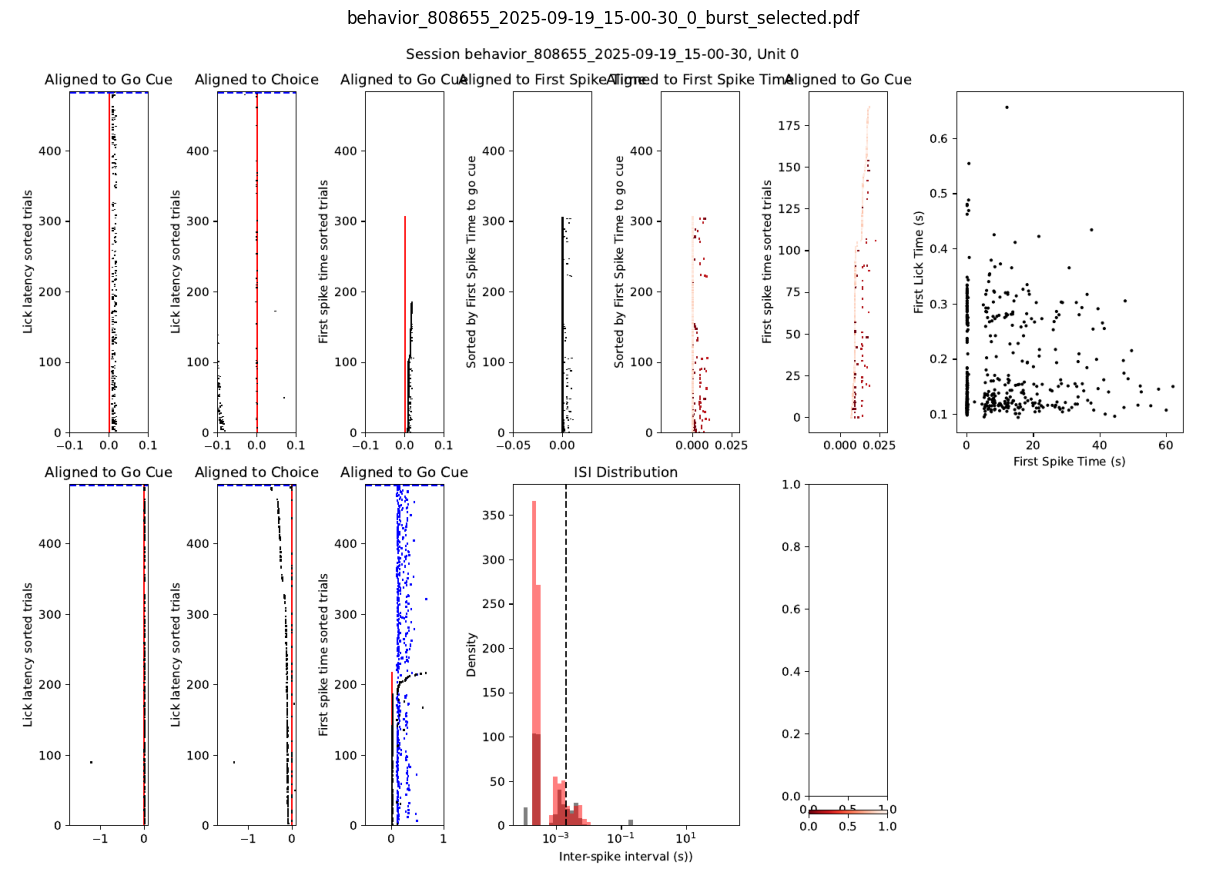

In [9]:
from pdf2image import convert_from_path

page = convert_from_path(pdfs[0], dpi=110)[0]
fig, ax = plt.subplots(figsize=(16, 11))
ax.imshow(page)
ax.axis('off')
ax.set_title(os.path.basename(pdfs[0]))
plt.show()

## 5. Batch, the way `__main__` does it

Same shape as the `if __name__ == '__main__'` block in `goCue_burst.py`, but scoped to sessions that
have a unit table. Keep `n_jobs=1` while debugging -- the joblib workers turn tracebacks into
`_RemoteTraceback` strings.

In [ ]:
def safe_process(session, data_type, units=None):
    try:
        burst_analysis(session, data_type, units=units)
    except Exception as e:
        print(f'Error processing session {session} for data type {data_type}: {e}')


session_list = ready.loc[ready['data_type'] == DATA_TYPE, 'session'].tolist()
Parallel(n_jobs=1)(delayed(safe_process)(session, DATA_TYPE) for session in session_list[:1])

## Reload after editing `goCue_burst.py`

In [ ]:
import importlib
import goCue_burst

importlib.reload(goCue_burst)
from goCue_burst import burst_analysis